K-Means

In [1]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

In [9]:
from sklearn import set_config

set_config(display="text")

In [10]:
# 테스트 데이터 생성
X, y = make_blobs(
    n_samples=300, 
    centers=4, 
    random_state=42
)

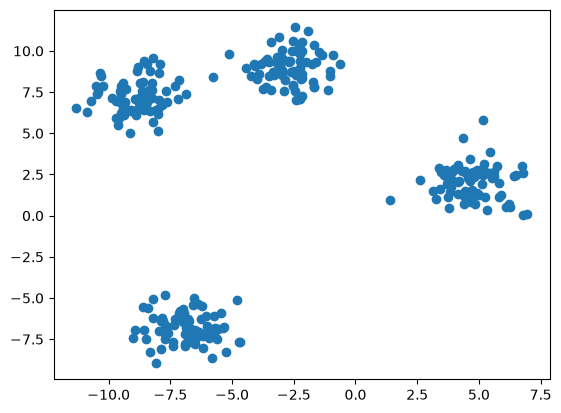

In [11]:
plt.scatter(X[:, 0], X[:, 1])

In [14]:
# 모델 생성
kmeans = KMeans(
    n_clusters=4,
    init="k-means++",
    random_state=42
)

In [17]:
cluster_labels = kmeans.fit_predict(X)

In [19]:
cluster_labels

array([3, 3, 0, 1, 3, 1, 2, 1, 0, 2, 0, 2, 0, 0, 3, 0, 3, 2, 0, 0, 2, 0,
       1, 3, 0, 3, 3, 1, 1, 2, 0, 2, 3, 2, 3, 0, 3, 1, 3, 1, 2, 0, 3, 1,
       0, 0, 3, 2, 3, 2, 1, 3, 1, 0, 1, 2, 3, 2, 2, 0, 3, 2, 2, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 3, 2, 0, 3, 1, 1, 0, 1, 0, 0, 3, 0, 1, 3, 3, 2,
       2, 2, 3, 0, 3, 0, 0, 3, 1, 0, 3, 3, 2, 2, 2, 0, 0, 0, 0, 0, 1, 3,
       2, 0, 0, 0, 0, 2, 3, 1, 3, 1, 1, 1, 0, 3, 1, 3, 3, 0, 3, 1, 2, 0,
       0, 0, 0, 2, 2, 3, 0, 1, 0, 2, 1, 0, 2, 2, 2, 2, 1, 0, 0, 3, 2, 1,
       0, 2, 1, 3, 3, 2, 0, 3, 1, 3, 2, 3, 1, 0, 0, 0, 0, 0, 1, 2, 2, 1,
       1, 2, 2, 1, 3, 0, 3, 2, 2, 3, 1, 0, 2, 2, 1, 1, 1, 3, 2, 1, 1, 2,
       2, 3, 0, 0, 1, 2, 0, 1, 1, 3, 1, 0, 0, 1, 1, 2, 3, 1, 3, 3, 0, 3,
       3, 1, 3, 1, 2, 2, 3, 3, 2, 2, 2, 3, 0, 1, 2, 1, 3, 2, 3, 3, 3, 1,
       1, 2, 3, 1, 1, 1, 3, 1, 3, 1, 3, 2, 1, 3, 2, 0, 3, 0, 2, 0, 3, 0,
       1, 2, 1, 2, 2, 0, 0, 1, 2, 2, 3, 3, 1, 0, 0, 2, 2, 2, 2, 1, 3, 2,
       1, 2, 2, 1, 0, 1, 2, 0, 3, 0, 2, 0, 3, 3], d

In [21]:
kmeans.cluster_centers_

array([[-2.70981136,  8.97143336],
       [-6.83235205, -6.83045748],
       [ 4.7182049 ,  2.04179676],
       [-8.87357218,  7.17458342]])

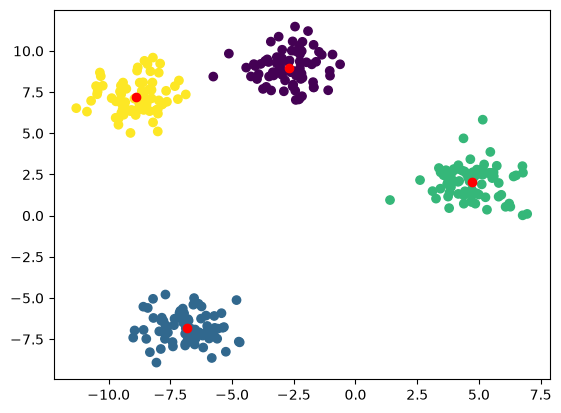

In [23]:
plt.scatter(X[:, 0], X[:, 1], cmap='viridis', c=cluster_labels)
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    c="red"
)

In [26]:
result = []

for k in range(1, 11):
    kmeans_temp = KMeans(n_clusters=k, init="k-means++", random_state=42)
    kmeans_temp.fit_predict(X)
    result.append(kmeans_temp.inertia_)

In [27]:
result

[19953.76914827803,
 9416.214004352272,
 2110.412521895329,
 564.9141808210252,
 513.0329042790798,
 462.0960007878174,
 411.3489318727926,
 365.3555992995912,
 332.03645710154757,
 291.5608624106775]

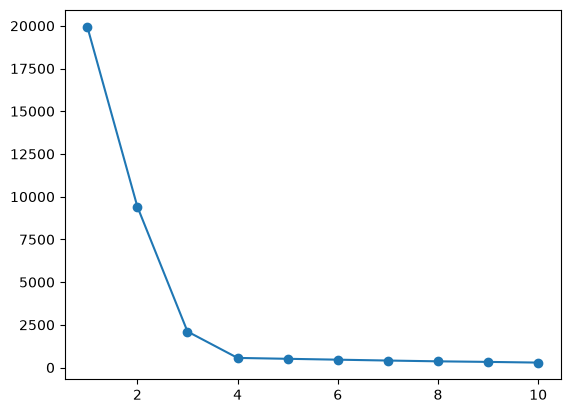

In [30]:
plt.plot(
    range(1, 11), result, marker="o"
)

In [31]:
# 실루엣 점수
from sklearn.metrics import silhouette_score, silhouette_samples

In [32]:
sil_score = silhouette_score(X, cluster_labels)
print(sil_score)

0.7915830011443039


In [33]:
sil_values = silhouette_samples(X, cluster_labels)
print(sil_values)

[0.80600451 0.80216071 0.73893458 0.87948243 0.71930267 0.90063471
 0.8710494  0.90827138 0.79909098 0.79917381 0.67810765 0.86416759
 0.66819132 0.67698901 0.81012669 0.77928758 0.75408624 0.72665936
 0.78160132 0.68083316 0.84037847 0.80749222 0.89582869 0.81516562
 0.78945463 0.6456291  0.7639259  0.7951111  0.90158165 0.82779032
 0.73468472 0.8178537  0.73802264 0.84127989 0.68750863 0.75713022
 0.74374922 0.91150739 0.79603318 0.82637541 0.8389285  0.81272915
 0.81488503 0.87235309 0.75172136 0.73802997 0.81210162 0.86328129
 0.80005662 0.81162246 0.90816901 0.68055866 0.8980895  0.74146687
 0.88514061 0.53179664 0.79581203 0.85366183 0.86145934 0.75707197
 0.74493573 0.76455439 0.85817039 0.0634864  0.88575261 0.88640631
 0.9001295  0.88313919 0.8544984  0.73852637 0.87870933 0.84510454
 0.79577041 0.87230205 0.70250671 0.79789834 0.83317117 0.89781966
 0.78855388 0.88348048 0.74987952 0.77679308 0.76667658 0.7801336
 0.8919131  0.72102419 0.67459466 0.80748076 0.81461896 0.78929

In [35]:
import numpy as np

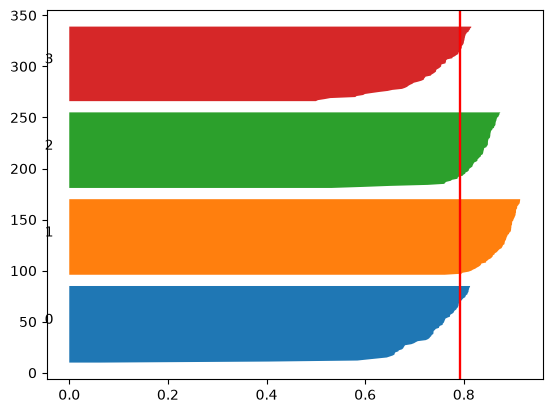

In [40]:
# 시각화 준비
y_lower=10
for i in range(4): # 각 클러스터에 대해 반복
    ith_cluster_silhouette_values = sil_values[cluster_labels==i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i  # 클러스터별 막대 그리기

    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values)
    plt.text(-0.05, y_lower+0.5*size_cluster_i, str(i)) # 클러스터 번호

    y_lower=y_upper+10# 다음 클러스터로 이동

    plt.axvline(x=sil_score, color='red')